In [1]:
import sys
import os
sys.path.insert(0, '..')
os.chdir('..')

## Chunk size ablation

The original project used 350 words as chunk size without testing whether that's actually optimal.
This notebook sweeps over a range of chunk sizes and measures hybrid retrieval hit rate at k=5.

Each run re-ingests the full corpus into a separate ChromaDB collection so the indexes don't interfere.
**This takes a while** — roughly 3-5 min per chunk size depending on hardware.

In [2]:
import json
import chromadb
from chromadb.utils.embedding_functions import OllamaEmbeddingFunction
from rank_bm25 import BM25Okapi
import matplotlib.pyplot as plt
import pandas as pd

from ingest import build_index

## Test set

Same questions as evalutation.ipynb — using a representative 50-question subset here
to keep the ablation runtime reasonable. Covers all categories proportionally.

In [3]:
test_set = [
    # seasons
    {"q": "Who won the 2021 F1 world championship?",                     "expected": "2021 Formula One World Championship"},
    {"q": "What controversy surrounded the 2021 Abu Dhabi Grand Prix?",  "expected": "2021 Formula One World Championship"},
    {"q": "Who won the 2023 F1 drivers championship?",                   "expected": "2023 Formula One World Championship"},
    {"q": "What happened to Ayrton Senna at the 1994 San Marino GP?",    "expected": "1994 Formula One World Championship"},
    {"q": "How did Hamilton win the 2008 championship on the last lap?",  "expected": "2008 Formula One World Championship"},
    {"q": "What was the main regulation change in the 2022 season?",      "expected": "2022 Formula One World Championship"},
    {"q": "Who did Verstappen beat to win the 2021 title?",              "expected": "2021 Formula One World Championship"},
    {"q": "What made the 2020 season unusual compared to other years?",  "expected": "2020 Formula One World Championship"},
    {"q": "How many different winners were there in the 2012 season?",   "expected": "2012 Formula One World Championship"},
    {"q": "Who won the 2016 F1 championship?",                           "expected": "2016 Formula One World Championship"},
    # drivers
    {"q": "When did Ayrton Senna die?",                                  "expected": "Ayrton Senna"},
    {"q": "How many world championships did Michael Schumacher win?",    "expected": "Michael Schumacher"},
    {"q": "How many championships has Lewis Hamilton won?",              "expected": "Lewis Hamilton"},
    {"q": "What team did Fernando Alonso win his championships with?",   "expected": "Fernando Alonso"},
    {"q": "What caused Romain Grosjean's crash in Bahrain 2020?",       "expected": "Romain Grosjean"},
    {"q": "What is Kimi Räikkönen's nickname?",                          "expected": "Kimi Räikkönen"},
    {"q": "What happened between Senna and Prost at the 1989 Japanese GP?", "expected": "Ayrton Senna"},
    {"q": "What two constructors did Niki Lauda win championships with?","expected": "Niki Lauda"},
    {"q": "How many pole positions does Hamilton have in his career?",   "expected": "Lewis Hamilton"},
    {"q": "What year did Jenson Button win the world championship?",     "expected": "Jenson Button"},
    {"q": "Who did Damon Hill lose the 1994 championship to?",           "expected": "Damon Hill"},
    {"q": "What team did Mika Häkkinen race for during his entire F1 career?", "expected": "Mika Häkkinen"},
    {"q": "How many races did Mansell win in his 1992 championship season?", "expected": "Nigel Mansell"},
    {"q": "What team did George Russell drive for before joining Mercedes?", "expected": "George Russell (racing driver)"},
    {"q": "What nationality is Oscar Piastri?",                          "expected": "Oscar Piastri"},
    # teams
    {"q": "When was Red Bull Racing founded?",                           "expected": "Red Bull Racing"},
    {"q": "How many constructors championships has Ferrari won?",        "expected": "Scuderia Ferrari"},
    {"q": "Which team dominated the hybrid era from 2014?",              "expected": "Mercedes AMG Petronas Formula One Team"},
    {"q": "Who founded Haas F1 team?",                                   "expected": "Haas F1 Team"},
    {"q": "What is the most successful constructor in F1 history?",      "expected": "Formula One World Constructors Championship"},
    # circuits
    {"q": "What is the famous corner at Spa called?",                    "expected": "Circuit de Spa-Francorchamps"},
    {"q": "What makes the Suzuka circuit layout unusual?",               "expected": "Suzuka Circuit"},
    {"q": "Where in the USA is the Circuit of the Americas located?",    "expected": "Circuit of the Americas"},
    {"q": "Why is Interlagos significant for F1 championship finales?",  "expected": "Autódromo José Carlos Pace"},
    {"q": "Why is the Hungaroring considered bad for overtaking?",       "expected": "Hungaroring"},
    {"q": "Who is the Circuit Gilles Villeneuve named after?",           "expected": "Circuit Gilles Villeneuve"},
    # topics
    {"q": "What is DRS and when can drivers use it?",                    "expected": "DRS (Formula One)"},
    {"q": "What is porpoising and why was it a problem in 2022?",        "expected": "Porpoising in Formula One"},
    {"q": "What does the safety car do in Formula One?",                 "expected": "Safety car (Formula One)"},
    {"q": "What are the different tyre compounds used in F1?",           "expected": "Formula One tyres"},
    {"q": "What is KERS and how does it work in Formula One?",           "expected": "Kinetic energy recovery system"},
    {"q": "How many people are typically involved in a modern F1 pit stop?", "expected": "Formula One pit stop"},
    {"q": "What does parc fermé mean in Formula One?",                   "expected": "Formula One regulations"},
    {"q": "What is ground effect and why was it banned in the early 80s?","expected": "Ground effect (cars)"},
    {"q": "What is a virtual safety car in Formula One?",                "expected": "Safety car (Formula One)"},
    {"q": "How many engines is an F1 driver allowed per season?",        "expected": "Formula One regulations"},
    # cross-article / harder questions (these were failure cases before ergast data)
    {"q": "Who had more podiums in total, Senna or Prost?",              "expected": "Ayrton Senna"},
    {"q": "What lap did the Safety Car come out in the 2021 Abu Dhabi finale?", "expected": "2021 Formula One World Championship"},
    {"q": "How many career wins did Alain Prost have?",                  "expected": "Alain Prost"},
    {"q": "What happened in the 2020 Bahrain GP involving Grosjean?",   "expected": "2020 Formula One World Championship"},
]
print(f"test set: {len(test_set)} questions")

test set: 50 questions


## Retrieval helpers

In [4]:
emb_fn = OllamaEmbeddingFunction(
    url="http://localhost:11434/api/embeddings",
    model_name="nomic-embed-text"
)
chroma_client = chromadb.PersistentClient(path=".chroma")

def dense_retrieve(collection, query, k=20):
    results = collection.query(query_texts=[query], n_results=k)
    return [
        {"id": id_, "text": doc, "source": meta["source"]}
        for id_, doc, meta in zip(
            results["ids"][0],
            results["documents"][0],
            results["metadatas"][0]
        )
    ]

def sparse_retrieve(bm25, all_ids, all_docs, all_metas, query, k=20):
    scores = bm25.get_scores(query.lower().split())
    top_i  = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:k]
    return [
        {"id": all_ids[i], "text": all_docs[i], "source": all_metas[i]["source"]}
        for i in top_i
    ]

def rrf(dense, sparse, k=60):
    scores, chunk_map = {}, {}
    for rank, c in enumerate(dense):
        scores[c["id"]]    = scores.get(c["id"], 0) + 1 / (k + rank + 1)
        chunk_map[c["id"]] = c
    for rank, c in enumerate(sparse):
        scores[c["id"]]    = scores.get(c["id"], 0) + 1 / (k + rank + 1)
        chunk_map[c["id"]] = c
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [{**chunk_map[cid], "rrf_score": s} for cid, s in ranked]

def hit_rate(collection, bm25, all_ids, all_docs, all_metas, test_set, k):
    hits = 0
    for item in test_set:
        d = dense_retrieve(collection, item["q"], 20)
        s = sparse_retrieve(bm25, all_ids, all_docs, all_metas, item["q"], 20)
        fused = rrf(d, s)[:k]
        if any(c["source"] == item["expected"] for c in fused):
            hits += 1
    return hits / len(test_set)

## Run the ablation

Each iteration:
1. builds a fresh ChromaDB collection with the given chunk size
2. loads BM25 from the temp chunks file
3. measures hit@3 and hit@5 on the test set

overlap is set to chunk_size // 7 to keep roughly the same overlap ratio as the original (50/350 ≈ 14%)

In [5]:
CHUNK_SIZES = [100, 200, 350, 500, 700]

results = []

for cs in CHUNK_SIZES:
    overlap   = max(10, cs // 7)
    coll_name = f"f1_docs_ablation_{cs}"
    cf        = f".chunks_ablation_{cs}.json"

    print(f"\n--- chunk_size={cs}, overlap={overlap} ---")
    build_index(chunk_size=cs, overlap=overlap, collection=coll_name, chunks_file=cf)

    with open(cf) as f:
        store = json.load(f)

    all_ids   = store["ids"]
    all_docs  = store["docs"]
    all_metas = store["metas"]
    bm25      = BM25Okapi([d.lower().split() for d in all_docs])

    coll = chroma_client.get_collection(coll_name, embedding_function=emb_fn)

    h3 = hit_rate(coll, bm25, all_ids, all_docs, all_metas, test_set, k=3)
    h5 = hit_rate(coll, bm25, all_ids, all_docs, all_metas, test_set, k=5)

    results.append({"chunk_size": cs, "overlap": overlap,
                    "n_chunks": len(all_docs), "hit@3": round(h3, 3), "hit@5": round(h5, 3)})
    print(f"  hit@3={h3:.3f}  hit@5={h5:.3f}  ({len(all_docs)} chunks)")

df = pd.DataFrame(results)
print("\n", df.to_string(index=False))


--- chunk_size=100, overlap=14 ---
ingesting 4469 chunks (size=100) from 56 Wikipedia + 0 Fandom + 23 Jolpica files...
  50/4469
  100/4469
  150/4469
  200/4469
  250/4469
  300/4469
  350/4469
  400/4469
  450/4469
  500/4469
  550/4469
  600/4469
  650/4469
  700/4469
  750/4469
  800/4469
  850/4469
  900/4469
  950/4469
  1000/4469
  1050/4469
  1100/4469
  1150/4469
  1200/4469
  1250/4469
  1300/4469
  1350/4469
  1400/4469
  1450/4469
  1500/4469
  1550/4469
  1600/4469
  1650/4469
  1700/4469
  1750/4469
  1800/4469
  1850/4469
  1900/4469
  1950/4469
  2000/4469
  2050/4469
  2100/4469
  2150/4469
  2200/4469
  2250/4469
  2300/4469
  2350/4469
  2400/4469
  2450/4469
  2500/4469
  2550/4469
  2600/4469
  2650/4469
  2700/4469
  2750/4469
  2800/4469
  2850/4469
  2900/4469
  2950/4469
  3000/4469
  3050/4469
  3100/4469
  3150/4469
  3200/4469
  3250/4469
  3300/4469
  3350/4469
  3400/4469
  3450/4469
  3500/4469
  3550/4469
  3600/4469
  3650/4469
  3700/4469
  3750/4469


## Plot

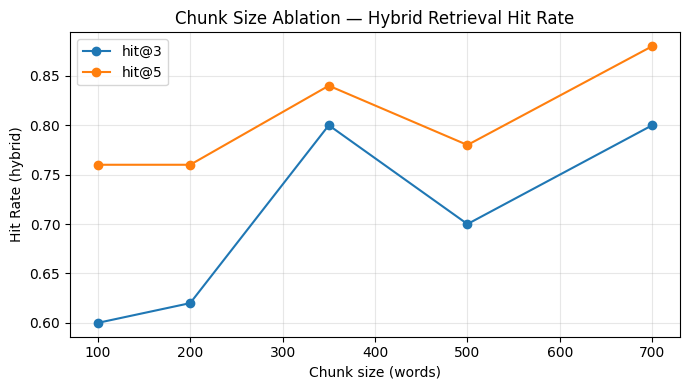

best hit@5: chunk_size=700


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["chunk_size"], df["hit@3"], marker="o", label="hit@3")
ax.plot(df["chunk_size"], df["hit@5"], marker="o", label="hit@5")
ax.set_xlabel("Chunk size (words)")
ax.set_ylabel("Hit Rate (hybrid)")
ax.set_title("Chunk Size Ablation — Hybrid Retrieval Hit Rate")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chunk_ablation.png", dpi=150)
plt.savefig("../chunk_ablation.png", dpi=150)
plt.show()
print(f"best hit@5: chunk_size={df.loc[df['hit@5'].idxmax(), 'chunk_size']}")

## Cleanup temp files (optional)

The ablation collections stay in `.chroma/` — remove them if you don't need them anymore.

In [7]:
# uncomment to delete temp collections and chunk files

# import os
# for cs in CHUNK_SIZES:
#     coll_name = f"f1_docs_ablation_{cs}"
#     cf        = f".chunks_ablation_{cs}.json"
#     try:
#         chroma_client.delete_collection(coll_name)
#     except:
#         pass
#     if os.path.exists(cf):
#         os.remove(cf)
# print("cleaned up")